In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
# -----------------------------
# Discretization
# -----------------------------
L = 1.0
R = 0.1
n = 20  # radial nodes including r=0 and r=R

r = np.linspace(0.0, R, n)
dr = r[1] - r[0]

# Interior radial nodes (exclude r=0 and r=R)
r_int = r[1:-1]              # size = n-2
n_int = r_int.size           # n_int = n-2

In [3]:
# -----------------------------
# Physical properties
# -----------------------------
v0 = 0.05
Dab = 1.2e-4
k = 1.2

# -----------------------------
# Initial condition
# -----------------------------
C0 = 5.0  # mol/m^3
y0 = C0 * np.ones(n_int)     # state contains ONLY interior nodes

print(f"n = {n}, dr = {dr:.6f}, interior state size = {y0.size}")

def reconstruct_full_C_from_interior(C_int, n, dr, Dab, k):
    """
    Reconstruct full C(z,r) including r=0 and r=R from interior nodes only.

    Parameters
    ----------
    C_int : array (m, n-2)
        Solution at interior nodes r[1]..r[n-2].
    Returns
    -------
    C_full : array (m, n)
        Reconstructed solution at all nodes r[0]..r[n-1].
    """
    m = C_int.shape[0]
    C_full = np.empty((m, n), dtype=float)

    # Fill interior nodes
    C_full[:, 1:-1] = C_int

    # Boundary at r=0 (second-order symmetry): C0 = (4*C1 - C2)/3
    C_full[:, 0] = (4.0 * C_full[:, 1] - C_full[:, 2]) / 3.0

    # Boundary at r=R (second-order Robin):
    # C_R = (4*C_{n-2} - C_{n-3}) / (3 + 2*k*dr/Dab)
    denom = 3.0 + 2.0 * k * dr / Dab
    C_full[:, -1] = (4.0 * C_full[:, -2] - C_full[:, -3]) / denom

    return C_full

def build_full_vector_from_state(y, n, dr, Dab, k):
    """
    Build a full vector C[0..n-1] from the interior-state vector y (length n-2),
    using second-order boundary reconstructions at r=0 and r=R.
    """
    C = np.empty(n, dtype=float)

    # Fill interior
    C[1:-1] = y

    # r=0 boundary (second-order symmetry)
    C[0] = (4.0 * C[1] - C[2]) / 3.0

    # r=R boundary (second-order Robin)
    denom = 3.0 + 2.0 * k * dr / Dab
    C[-1] = (4.0 * C[-2] - C[-3]) / denom

    return C

n = 20, dr = 0.005263, interior state size = 18


In [4]:
def modelo(z, y, n, r_int, dr, v0, Dab, k, R):
    """
    Part (a): v(r) = v0 (uniform / plug flow).
    State y has length n-2 corresponding to r[1]..r[n-2].
    """
    C = build_full_vector_from_state(y, n, dr, Dab, k)

    dy = np.zeros_like(y)

    # Interior indices in the full vector correspond to i = 1..n-2
    # State index j corresponds to full index i = j+1
    for j in range(y.size):
        i = j + 1
        term1 = (C[i + 1] - C[i - 1]) / (r[i] * 2.0 * dr)
        term2 = (C[i + 1] - 2.0 * C[i] + C[i - 1]) / (dr ** 2)
        dy[j] = (Dab / v0) * (term1 + term2)

    return dy

def modelo2(z, y, n, r_int, dr, v0, Dab, k, R):
    """
    Part (b): v(r) = 2*v0*(1-(r/R)^2) (parabolic profile).
    State y has length n-2 corresponding to r[1]..r[n-2].
    """
    C = build_full_vector_from_state(y, n, dr, Dab, k)

    dy = np.zeros_like(y)

    for j in range(y.size):
        i = j + 1
        v_i = 2.0 * v0 * (1.0 - (r[i] / R) ** 2)
        term1 = (C[i + 1] - C[i - 1]) / (r[i] * 2.0 * dr)
        term2 = (C[i + 1] - 2.0 * C[i] + C[i - 1]) / (dr ** 2)
        dy[j] = (Dab / v_i) * (term1 + term2)

    return dy

In [5]:
# -----------------------------
# Integration: Part (a)
# -----------------------------
sol_a = solve_ivp(
    fun=lambda z, y: modelo(z, y, n, r_int, dr, v0, Dab, k, R),
    t_span=(0.0, L),
    y0=y0,
    method="BDF",
    rtol=1e-9,
    atol=1e-12
)

z_a = sol_a.t
C_a_full = reconstruct_full_C_from_interior(sol_a.y.T, n, dr, Dab, k)

print("Part (a) integration complete.")
print("z points:", z_a.size, "| C_a_full shape:", C_a_full.shape)

Part (a) integration complete.
z points: 342 | C_a_full shape: (342, 20)


In [6]:
# -----------------------------
# Integration: Part (b)
# -----------------------------
sol_b = solve_ivp(
    fun=lambda z, y: modelo2(z, y, n, r_int, dr, v0, Dab, k, R),
    t_span=(0.0, L),
    y0=y0,
    method="BDF",
    rtol=1e-9,
    atol=1e-12
)

z_b = sol_b.t
C_b_full = reconstruct_full_C_from_interior(sol_b.y.T, n, dr, Dab, k)

print("Part (b) integration complete.")
print("z points:", z_b.size, "| C_b_full shape:", C_b_full.shape)

Part (b) integration complete.
z points: 410 | C_b_full shape: (410, 20)


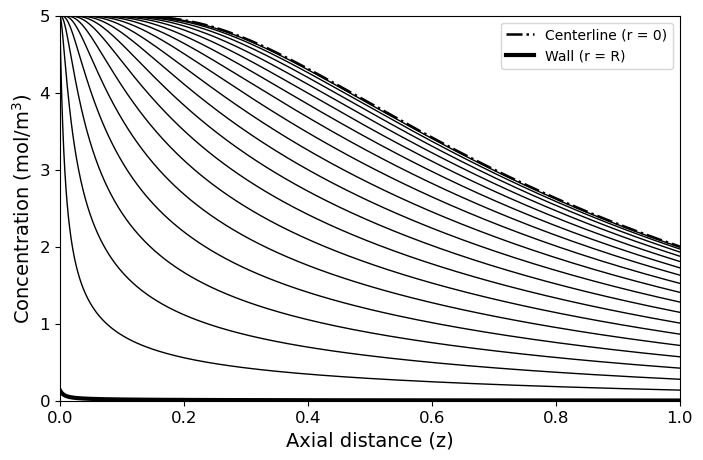

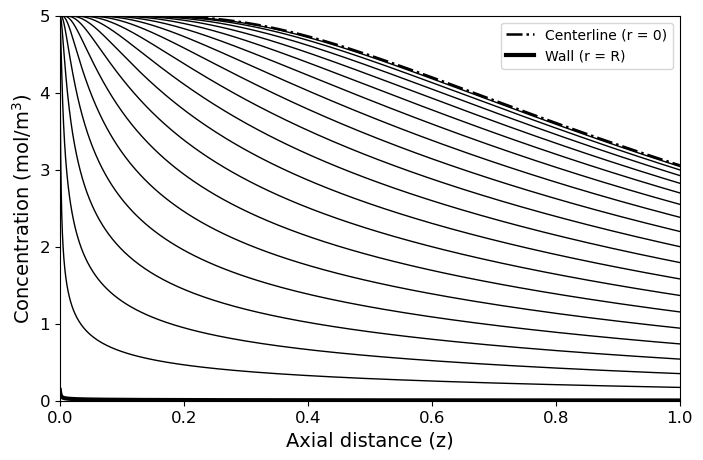

In [7]:
# -----------------------------
# 2D plots (black lines + highlighted centerline and wall)
# -----------------------------
# (a) Uniform velocity
plt.figure(figsize=(8, 5))

# All interior radial nodes (thin black, no legend entry)
plt.plot(z_a, C_a_full[:, 1:-1], color="black", lw=1.0)

# Centerline r=0 (dash-dot, legend entry)
plt.plot(z_a, C_a_full[:, 0], color="black", lw=1.8, ls="-.",
         label="Centerline (r = 0)")

# Wall r=R (thick solid, legend entry)
plt.plot(z_a, C_a_full[:, -1], color="black", lw=3.0, ls="-",
         label="Wall (r = R)")

plt.axis([0, 1, 0, 5])
plt.xlabel("Axial distance (z)", fontsize=14)
plt.ylabel("Concentration (mol/m$^3$)", fontsize=14)
plt.tick_params(axis='both', labelsize=12)
# plt.title(f"(a) Concentration profiles (uniform velocity), n = {n}")
plt.legend()
plt.show()

# (b) Parabolic velocity
plt.figure(figsize=(8, 5))

plt.plot(z_b, C_b_full[:, 1:-1], color="black", lw=1.0)
plt.plot(z_b, C_b_full[:, 0], color="black", lw=1.8, ls="-.",
         label="Centerline (r = 0)")
plt.plot(z_b, C_b_full[:, -1], color="black", lw=3.0, ls="-",
         label="Wall (r = R)")

plt.axis([0, 1, 0, 5])
plt.xlabel("Axial distance (z)", fontsize=14)
plt.ylabel("Concentration (mol/m$^3$)", fontsize=14)
plt.tick_params(axis='both', labelsize=12)
# plt.title(f"(b) Concentration profiles (parabolic velocity), n = {n}")
plt.legend()

plt.show()

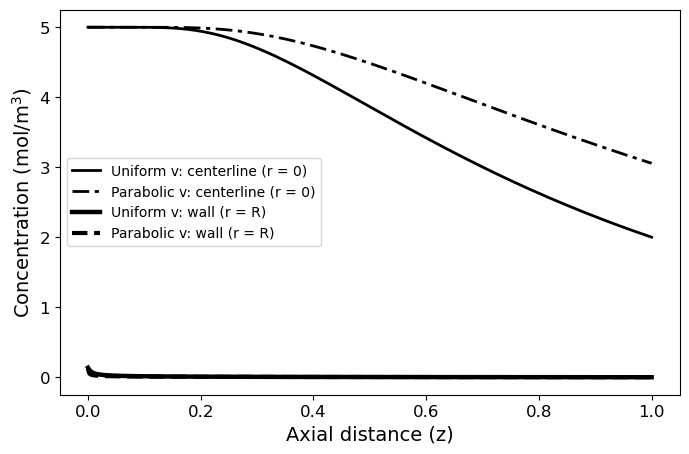

In [8]:
# -----------------------------
# Comparison at r=0 and r=R
# -----------------------------
i_center = 0
i_wall = n - 1

plt.figure(figsize=(8, 5))

# Centerline
plt.plot(z_a, C_a_full[:, i_center], color="black", lw=2.0, ls="-",
         label="Uniform v: centerline (r = 0)")
plt.plot(z_b, C_b_full[:, i_center], color="black", lw=2.0, ls="-",
         dashes=(6, 2, 1.5, 2), label="Parabolic v: centerline (r = 0)")

# Wall
plt.plot(z_a, C_a_full[:, i_wall], color="black", lw=3.2, ls="-",
         label="Uniform v: wall (r = R)")
plt.plot(z_b, C_b_full[:, i_wall], color="black", lw=3.0, ls="--",
         label="Parabolic v: wall (r = R)")

plt.xlabel("Axial distance (z)", fontsize=14)
plt.ylabel("Concentration (mol/m$^3$)", fontsize=14)
plt.tick_params(axis='both', labelsize=12)
# plt.title("Comparison of concentration profiles at r = 0 and r = R")
plt.legend(loc='center left')

plt.show()
